# PyTorch 实现 MNIST Logistic Regression

这个 notebook 用最简单的 PyTorch 代码实现 MNIST 10 类分类。

本节只使用一个线性层：

```python
model = nn.Linear(784, 10)
```


数学上，对一个 mini-batch：

$$
X \in \mathbb{R}^{B \times 784}, \quad S = XW + b, \quad S \in \mathbb{R}^{B \times 10}
$$

其中 $B$ 是 batch size，$S$ 是 logits。

## 1. 准备环境

这个例子可以在 CPU 上运行。第一次运行会通过 `torchvision` 下载 MNIST 到仓库的 `data/` 目录。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="white", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 150

# Keep the first version CPU-only so students do not need GPU knowledge.
device = torch.device("cpu")

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "dl_intro" else Path.cwd()
DATA_DIR = REPO_ROOT / "data"

## 2. 准备 MNIST 数据

`transforms.ToTensor()` 会把每张图片从 0 到 255 的整数像素，转换成 0 到 1 的浮点数 tensor。

训练时，`DataLoader` 会把很多张图片组成 mini-batch。例如 batch size 为 128 时：

- `images.shape = (128, 1, 28, 28)`
- `labels.shape = (128,)`

之后我们会把图片展平为 `X.shape = (128, 784)`。

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

print(f"number of training images = {len(train_dataset)}")
print(f"number of test images = {len(test_dataset)}")

number of training images = 60000
number of test images = 10000


## 3. 超参数：batch size、learning rate、epochs

训练前需要先设定几个简单的超参数：

- `BATCH_SIZE`: 每次用多少张图片估计梯度。
- `LEARNING_RATE`: 每次参数更新走多大一步。
- `EPOCHS`: 把训练集完整看几遍。

learning rate 很重要：

- 太小：训练很慢，loss 下降不明显。
- 太大：更新步子过大，loss 可能震荡甚至变差。

同学们可以自己尝试改 `LEARNING_RATE`，例如 `0.01`、`0.1`、`0.5`，观察最后 accuracy 和训练曲线的变化。

In [3]:
BATCH_SIZE = 128
LEARNING_RATE = 0.1
EPOCHS = 10

# Set this to True if you only want to check that the notebook runs quickly.
FAST_DEV_RUN = False

if FAST_DEV_RUN:
    train_dataset = Subset(train_dataset, range(2048))
    test_dataset = Subset(test_dataset, range(512))
    EPOCHS = 1

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"batch size = {BATCH_SIZE}")
print(f"learning rate = {LEARNING_RATE}")
print(f"epochs = {EPOCHS}")

batch size = 128
learning rate = 0.1
epochs = 10


看一个 mini-batch 的形状。这里的 `X` 就是模型真正接收的输入矩阵。

In [4]:
images, labels = next(iter(train_loader))

# Each image is flattened from 1 x 28 x 28 into a 784-dimensional vector.
X = images.view(images.shape[0], -1)

print(f"images.shape = {tuple(images.shape)}")
print(f"X.shape = {tuple(X.shape)}")
print(f"labels.shape = {tuple(labels.shape)}")

images.shape = (128, 1, 28, 28)
X.shape = (128, 784)
labels.shape = (128,)


## 4. 模型：只有一个线性层

这个模型就是多分类 logistic regression。它对每张图片输出 10 个 logits，对应数字 0 到 9。

注意：PyTorch 的 `nn.Linear(784, 10)` 内部权重 `model.weight` 的形状是 `(10, 784)`。这和数学里常写的 $W \in \mathbb{R}^{784 \times 10}$ 是转置关系，但表示的是同一个线性映射。

In [5]:
model = nn.Linear(28 * 28, 10).to(device)

print(model)
print(f"weight shape = {tuple(model.weight.shape)}")
print(f"bias shape = {tuple(model.bias.shape)}")

Linear(in_features=784, out_features=10, bias=True)
weight shape = (10, 784)
bias shape = (10,)


做一次 forward pass，确认输出形状。

- 输入 `X.shape = (B, 784)`
- 输出 `logits.shape = (B, 10)`

`logits` 是原始分数，不是概率。训练时直接把 logits 交给 `nn.CrossEntropyLoss()`。

In [6]:
logits = model(X.to(device))

print(f"logits.shape = {tuple(logits.shape)}")
print("first image logits:")
print(logits[0].detach())

logits.shape = (128, 10)
first image logits:
tensor([-0.1215, -0.3348,  0.2435,  0.2003, -0.2909, -0.0312,  0.1894,  0.1724,
         0.1156,  0.2130])


## 5. Loss 和 optimizer

我们使用：

- `nn.CrossEntropyLoss()`：比较 logits 和真实标签，得到分类 loss。
- `torch.optim.SGD`：stochastic gradient descent，用梯度更新参数。

训练循环的核心顺序是：

```python
optimizer.zero_grad()
logits = model(X)
loss = criterion(logits, labels)
loss.backward()
optimizer.step()
```

`zero_grad()` 很重要，因为 PyTorch 默认会累加梯度。每个 mini-batch 更新前都要先清空旧梯度。

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

## 6. 训练一个 mini-batch：看清楚每一步

先只对一个 mini-batch 做一次更新，理解 PyTorch 训练的基本动作。后面再写完整训练循环。

In [8]:
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

# Flatten images: (B, 1, 28, 28) -> (B, 784).
X = images.view(images.shape[0], -1)

# Gradients from previous mini-batches must be cleared before a new update.
optimizer.zero_grad()

# Forward computation builds a computational graph from X to loss.
logits = model(X)
loss = criterion(logits, labels)

# Backward propagation computes gradients for model.weight and model.bias.
loss.backward()

# SGD updates parameters using: parameter <- parameter - learning_rate * gradient.
optimizer.step()

## 7. 完整训练循环

为了让训练结果更清楚，下面重新初始化模型，然后从头训练。每个 epoch 结束后记录平均 loss 和 training accuracy。

In [9]:
torch.manual_seed(SEED)
model = nn.Linear(28 * 28, 10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Convert a batch of images into a batch of 784-dimensional vectors.
        X = images.view(images.shape[0], -1)

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size

        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += batch_size

    train_loss = total_loss / total
    train_accuracy = correct / total
    history.append({"epoch": epoch + 1, "train_loss": train_loss, "train_accuracy": train_accuracy})

    print(f"epoch {epoch + 1}: loss = {train_loss:.4f}, train accuracy = {train_accuracy:.4f}")

history_df = pd.DataFrame(history)
history_df

epoch 1: loss = 0.5724, train accuracy = 0.8621
epoch 2: loss = 0.3741, train accuracy = 0.8973
epoch 3: loss = 0.3427, train accuracy = 0.9044
epoch 4: loss = 0.3262, train accuracy = 0.9090
epoch 5: loss = 0.3155, train accuracy = 0.9122
epoch 6: loss = 0.3081, train accuracy = 0.9142
epoch 7: loss = 0.3022, train accuracy = 0.9160
epoch 8: loss = 0.2974, train accuracy = 0.9171
epoch 9: loss = 0.2937, train accuracy = 0.9176
epoch 10: loss = 0.2905, train accuracy = 0.9191


,epoch,train_loss,train_accuracy
0,1,0.572387,0.862083
1,2,0.374137,0.897317
2,3,0.342650,0.904417
3,4,0.326187,0.908983
4,5,0.315451,0.912167
5,6,0.308055,0.914200
6,7,0.302174,0.916033
7,8,0.297429,0.917050
8,9,0.293671,0.917567
9,10,0.290498,0.919050


训练过程中，loss 应该整体下降，accuracy 应该整体上升。由于这里只是一个线性模型，效果不会像卷积神经网络那样高，但已经能明显学到数字分类规律。

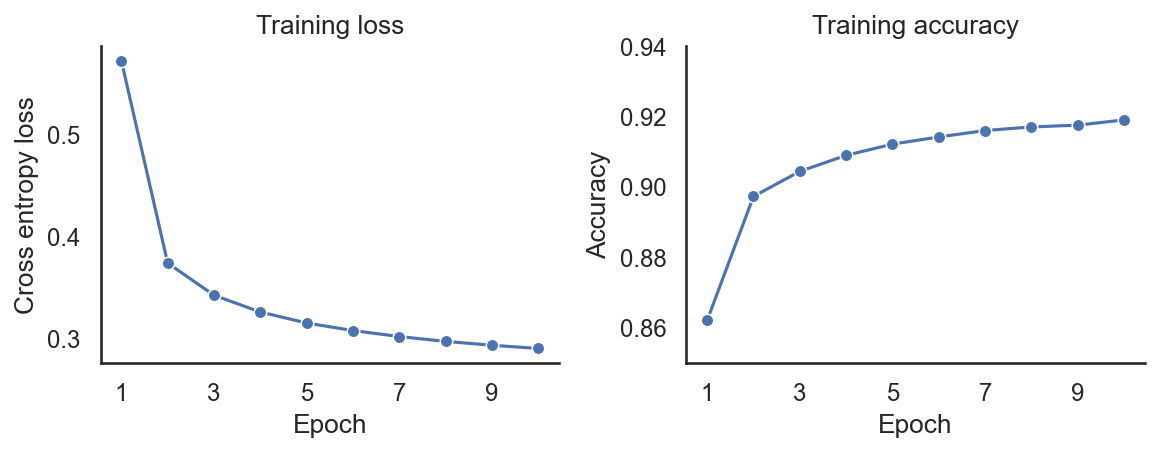

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))

sns.lineplot(data=history_df, x="epoch", y="train_loss", marker="o", ax=axes[0])
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross entropy loss")

sns.lineplot(data=history_df, x="epoch", y="train_accuracy", marker="o", ax=axes[1])
axes[1].set_title("Training accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.85, 0.94)

xticks = history_df["epoch"][::2]

for axis in axes:
    axis.set_xticks(xticks)
    sns.despine(ax=axis)

plt.tight_layout()
plt.show()

## 8. 在 test set 上汇报 accuracy

训练结束后，用 test set 做最终评估。评估时使用 `torch.no_grad()`，因为我们只需要 forward pass，不需要计算梯度。

test set accuracy和training set比如何？高还是低？为什么？

In [11]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        X = images.view(images.shape[0], -1)
        logits = model(X)
        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.shape[0]

test_accuracy = correct / total
print(f"test accuracy = {test_accuracy:.4f}")

test accuracy = 0.9209


## 9. 看几张预测错误的图片

最后看几张模型预测错误的 test images。错误样本通常比整体 accuracy 更有教学价值，因为它们能帮助我们观察模型在哪些情况下容易混淆。

In [12]:
model.eval()
misclassified_images = []
misclassified_true_labels = []
misclassified_pred_labels = []
max_examples = 8

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        X = images.view(images.shape[0], -1)
        logits = model(X)
        predictions = logits.argmax(dim=1)

        wrong_mask = predictions != labels
        wrong_indices = torch.where(wrong_mask)[0]

        for index in wrong_indices:
            # Move tensors back to CPU so matplotlib can display them.
            misclassified_images.append(images[index].cpu())
            misclassified_true_labels.append(labels[index].cpu().item())
            misclassified_pred_labels.append(predictions[index].cpu().item())

            if len(misclassified_images) >= max_examples:
                break

        if len(misclassified_images) >= max_examples:
            break

print(f"collected {len(misclassified_images)} misclassified test images")

collected 8 misclassified test images


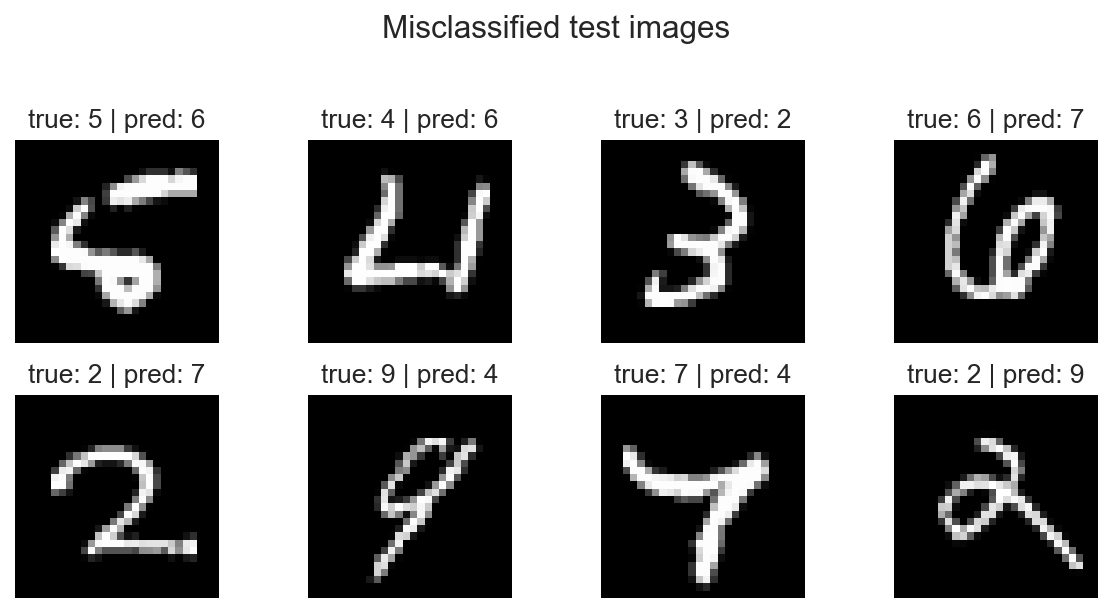

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
axes = axes.ravel()

for axis, image, true_label, pred_label in zip(
    axes,
    misclassified_images,
    misclassified_true_labels,
    misclassified_pred_labels,
):
    axis.imshow(image.squeeze(0), cmap="gray")
    axis.set_title(f"true: {true_label} | pred: {pred_label}")
    axis.axis("off")

# If fewer than 8 mistakes were collected, hide the unused panels.
for axis in axes[len(misclassified_images):]:
    axis.axis("off")

plt.suptitle("Misclassified test images", y=1.02)
plt.tight_layout()
plt.show()

## 10. 可以自己尝试的调参问题

保持模型仍然只有一个线性层，尝试改变这些设置：

- 把 `LEARNING_RATE` 改成 `0.01`、`0.1`、`0.5`，训练曲线有什么变化？
- 把 `EPOCHS` 改成 `1`、`3`、`5`，test accuracy 会继续提高吗？
- 把 `BATCH_SIZE` 改成 `32` 或 `256`，训练速度和结果有什么变化？

观察重点不是追求最高分，而是理解 learning rate、batch size 和 epochs 如何影响训练。